# 🤖 Notebook 07 — Clustering, Segmentação e Matriz de Correlação (Olist)

**Objetivo:** Aplicar técnicas de Machine Learning não-supervisionado (**K-Means Clustering**, **Hierarchical Clustering** / Dendrograma), gerar a segmentação de clientes (**RFM**), segmentação de vendedores, matriz de correlação completa e matriz BCG de categorias.

## 1. Importações e Configurações

In [1]:
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Configuração de estilo visual
sns.set_theme(style="whitegrid")
plt.rcParams['figure.figsize'] = (10, 6)
plt.rcParams['font.size'] = 11

# Detecção dinâmica de caminhos para dados e outputs
DATA_DIR = '../data/olist' if os.path.exists('../data/olist') else 'data/olist'
if not os.path.exists(DATA_DIR):
    DATA_DIR = '/home/jorge/Documents/tech-challenge-agentes-ia/data/olist'

OUTPUT_DIR = './outputs' if os.path.exists('./outputs') or os.path.basename(os.getcwd()) == 'notebooks' else 'notebooks/outputs'
os.makedirs(OUTPUT_DIR, exist_ok=True)

print(f"📁 Diretório de Dados: {os.path.abspath(DATA_DIR)}")
print(f"📁 Diretório de Outputs: {os.path.abspath(OUTPUT_DIR)}")

from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA
from sklearn.metrics import silhouette_score
from scipy.cluster.hierarchy import dendrogram, linkage


📁 Diretório de Dados: /home/jorge/Documents/tech-challenge-agentes-ia/data/olist
📁 Diretório de Outputs: /home/jorge/Documents/tech-challenge-agentes-ia/notebooks/outputs


## 2. Segmentação de Clientes (Análise RFM)

In [2]:
orders = pd.read_csv(os.path.join(DATA_DIR, 'olist_orders_dataset.csv'))
customers = pd.read_csv(os.path.join(DATA_DIR, 'olist_customers_dataset.csv'))
payments = pd.read_csv(os.path.join(DATA_DIR, 'olist_order_payments_dataset.csv'))

orders['order_purchase_timestamp'] = pd.to_datetime(orders['order_purchase_timestamp'])
cust_orders = orders.merge(customers, on='customer_id').merge(payments, on='order_id')

ref_date = cust_orders['order_purchase_timestamp'].max() + pd.Timedelta(days=1)

# Cálculo de Recência, Frequência e Valor Monetário
rfm = cust_orders.groupby('customer_unique_id').agg(
    Recency=('order_purchase_timestamp', lambda x: (ref_date - x.max()).days),
    Frequency=('order_id', 'nunique'),
    Monetary=('payment_value', 'sum')
).reset_index()

print("✓ Resumo das Métricas RFM:")
display(rfm.describe().T)


✓ Resumo das Métricas RFM:


,count,mean,std,min,25%,50%,75%,max
Recency,96095.0,288.730756,153.407846,1.0,164.00,269.0,398.00,773.00
Frequency,96095.0,1.034809,0.214385,1.0,1.00,1.0,1.00,17.00
Monetary,96095.0,166.594226,231.428912,0.0,63.12,108.0,183.53,13664.08


## 3. K-Means Clustering em Clientes (Elbow & Silhouette)

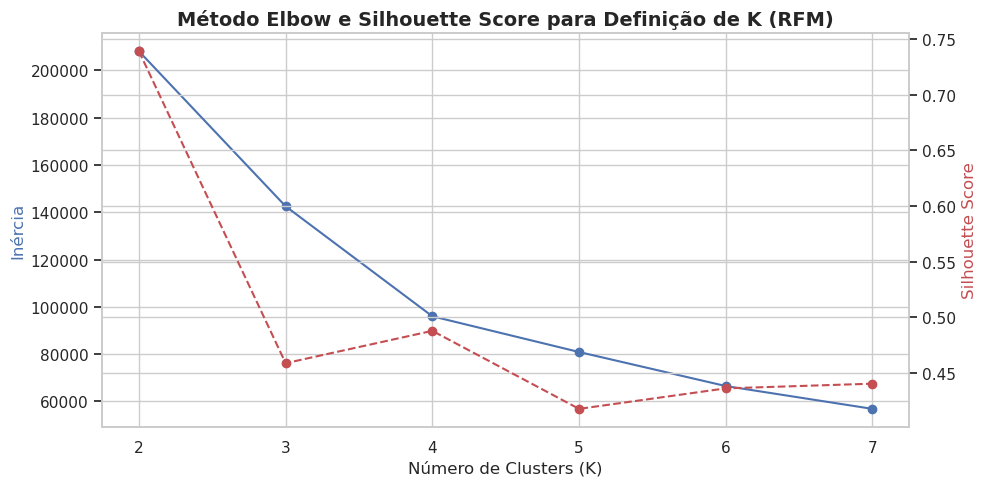

In [3]:
scaler = StandardScaler()
rfm_scaled = scaler.fit_transform(rfm[['Recency', 'Frequency', 'Monetary']])

inertias = []
silhouettes = []
K_range = range(2, 8)

for k in K_range:
    km = KMeans(n_clusters=k, random_state=42, n_init=10)
    labels = km.fit_predict(rfm_scaled)
    inertias.append(km.inertia_)
    # Sample for silhouette score for fast execution
    sample_idx = np.random.choice(len(rfm_scaled), size=min(10000, len(rfm_scaled)), replace=False)
    silhouettes.append(silhouette_score(rfm_scaled[sample_idx], labels[sample_idx]))

fig, ax1 = plt.subplots(figsize=(10, 5))
ax1.plot(K_range, inertias, 'bo-', label='Inércia (Elbow)')
ax1.set_xlabel('Número de Clusters (K)')
ax1.set_ylabel('Inércia', color='b')

ax2 = ax1.twinx()
ax2.plot(K_range, silhouettes, 'ro--', label='Silhouette Score')
ax2.set_ylabel('Silhouette Score', color='r')

plt.title('Método Elbow e Silhouette Score para Definição de K (RFM)', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, 'kmeans_elbow_silhouette.png'))
plt.show()


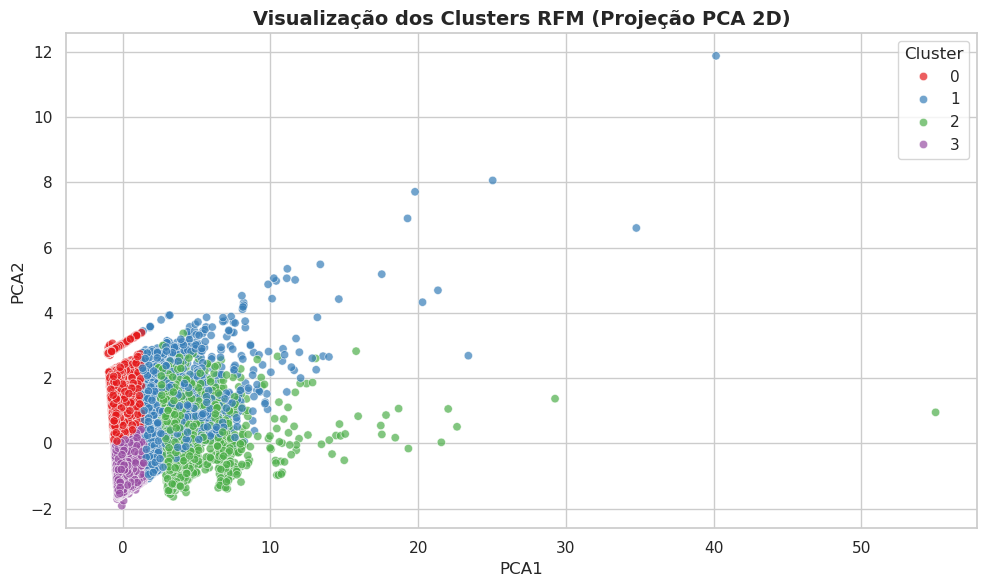

📊 Perfil dos Clusters de Clientes (RFM):


,Recencia_Media,Frequencia_Media,Monetario_Medio,Tamanho
Cluster,,,,
0,438.803699,1.000000,134.926653,38655
1,289.490091,1.015690,1196.225244,2422
2,269.306212,2.116475,290.305945,2962
3,178.361668,1.000000,135.164795,52056


In [4]:
# Treinar modelo K-Means final com K=4
kmeans_final = KMeans(n_clusters=4, random_state=42, n_init=10)
rfm['Cluster'] = kmeans_final.fit_predict(rfm_scaled)

# Projeção 2D com PCA
pca = PCA(n_components=2)
rfm_pca = pca.fit_transform(rfm_scaled)
rfm['PCA1'] = rfm_pca[:, 0]
rfm['PCA2'] = rfm_pca[:, 1]

plt.figure(figsize=(10, 6))
sns.scatterplot(data=rfm, x='PCA1', y='PCA2', hue='Cluster', palette='Set1', alpha=0.7)
plt.title('Visualização dos Clusters RFM (Projeção PCA 2D)', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, 'kmeans_pca_clusters.png'))
plt.show()

# Perfil dos Clusters
cluster_profile = rfm.groupby('Cluster').agg(
    Recencia_Media=('Recency', 'mean'),
    Frequencia_Media=('Frequency', 'mean'),
    Monetario_Medio=('Monetary', 'mean'),
    Tamanho=('customer_unique_id', 'count')
)
print("📊 Perfil dos Clusters de Clientes (RFM):")
display(cluster_profile)


## 4. Clustering Hierárquico (Dendrograma)

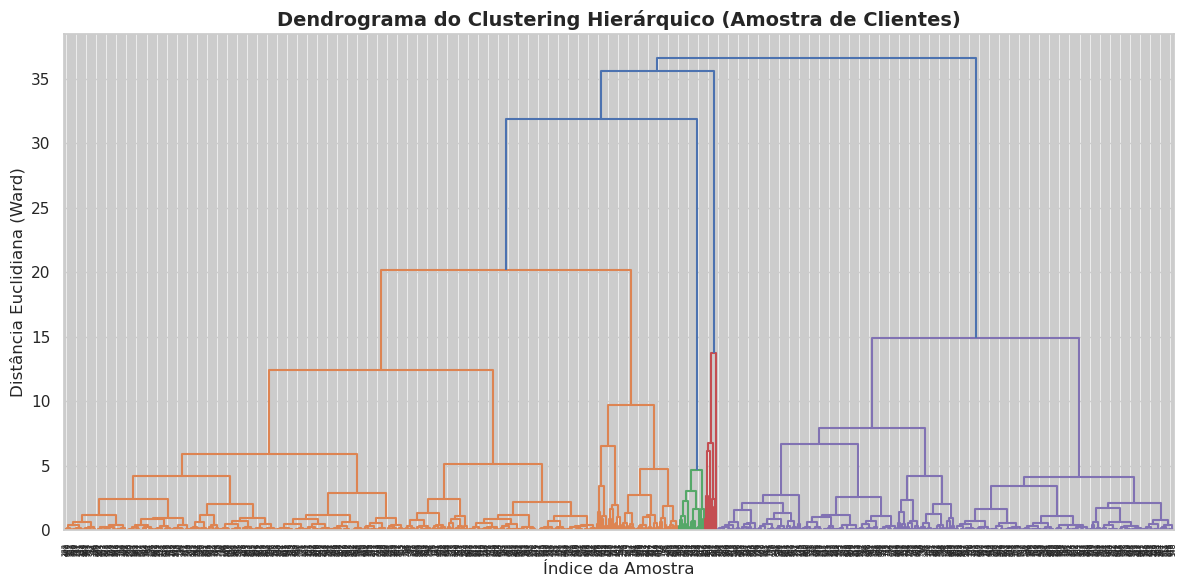

In [5]:
# Amostragem para dendrograma (1000 registros para legibilidade)
sample_rfm = rfm_scaled[:1000]
linked = linkage(sample_rfm, method='ward')

plt.figure(figsize=(12, 6))
dendrogram(linked, orientation='top', distance_sort='descending', show_leaf_counts=False)
plt.title('Dendrograma do Clustering Hierárquico (Amostra de Clientes)', fontsize=14, fontweight='bold')
plt.xlabel('Índice da Amostra')
plt.ylabel('Distância Euclidiana (Ward)')
plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, 'hierarchical_dendrogram.png'))
plt.show()


## 5. Segmentação de Vendedores (K=3)

In [6]:
items = pd.read_csv(os.path.join(DATA_DIR, 'olist_order_items_dataset.csv'))
reviews = pd.read_csv(os.path.join(DATA_DIR, 'olist_order_reviews_dataset.csv'))
products = pd.read_csv(os.path.join(DATA_DIR, 'olist_products_dataset.csv'))

seller_data = items.merge(reviews, on='order_id', how='left').merge(products, on='product_id', how='left')

seller_features = seller_data.groupby('seller_id').agg(
    receita_total=('price', 'sum'),
    total_pedidos=('order_id', 'nunique'),
    review_medio=('review_score', 'mean'),
    variedade_produtos=('product_id', 'nunique')
).fillna(0)

s_scaler = StandardScaler()
s_scaled = s_scaler.fit_transform(seller_features)

km_seller = KMeans(n_clusters=3, random_state=42, n_init=10)
seller_features['Cluster_Seller'] = km_seller.fit_predict(s_scaled)

seller_clusters = seller_features.groupby('Cluster_Seller').agg(
    Receita_Media=('receita_total', 'mean'),
    Pedidos_Medios=('total_pedidos', 'mean'),
    Review_Medio=('review_medio', 'mean'),
    Produtos_Diferentes=('variedade_produtos', 'mean'),
    Quantidade=('receita_total', 'count')
)

print("🏪 Perfil dos Clusters de Vendedores:")
display(seller_clusters)


🏪 Perfil dos Clusters de Vendedores:


,Receita_Media,Pedidos_Medios,Review_Medio,Produtos_Diferentes,Quantidade
Cluster_Seller,,,,,
0,3810.792265,27.734479,4.325295,10.820773,2561
1,102985.945152,807.696970,4.026667,161.969697,33
2,985.924731,4.646707,2.131058,2.776447,501


## 6. Matriz de Correlação Completa das Métricas do Negócio

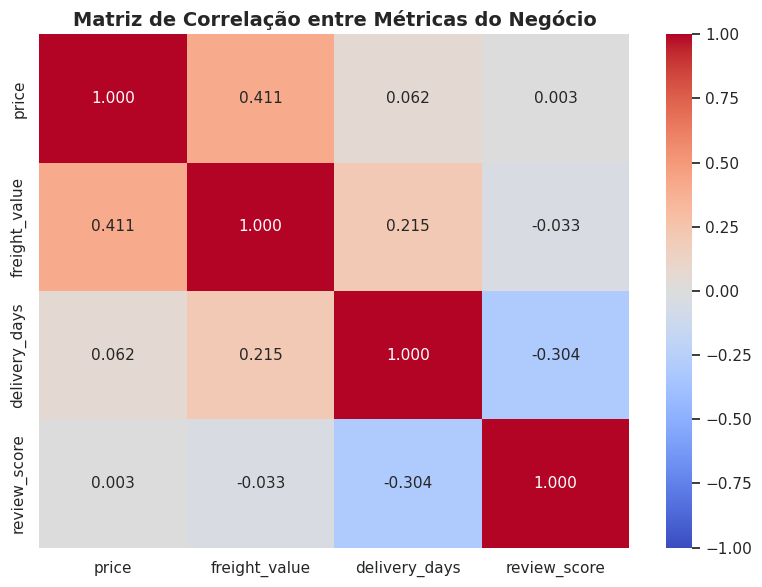

In [7]:
orders_deliv = orders.dropna(subset=['order_delivered_customer_date']).copy()
orders_deliv['delivery_days'] = (pd.to_datetime(orders_deliv['order_delivered_customer_date']) - pd.to_datetime(orders_deliv['order_purchase_timestamp'])).dt.total_seconds() / (24*3600)

full_metrics = items.merge(orders_deliv, on='order_id').merge(reviews, on='order_id', how='left')

corr_vars = full_metrics[['price', 'freight_value', 'delivery_days', 'review_score']].dropna()
corr_matrix = corr_vars.corr()

plt.figure(figsize=(8, 6))
sns.heatmap(corr_matrix, annot=True, fmt='.3f', cmap='coolwarm', vmin=-1, vmax=1)
plt.title('Matriz de Correlação entre Métricas do Negócio', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, 'correlation_matrix.png'))
plt.show()


## 7. Matriz BCG de Categorias de Produtos

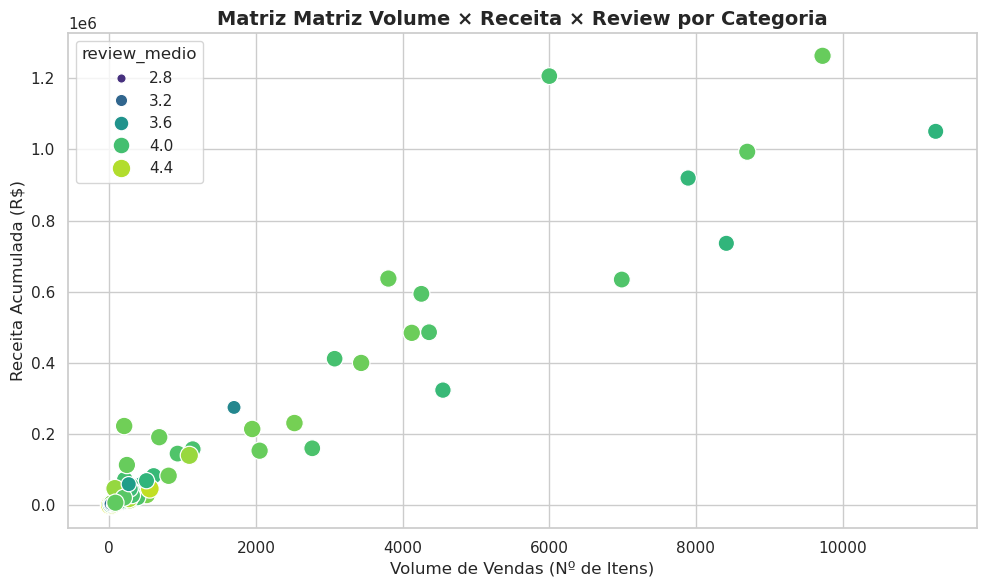

In [8]:
cat_summary = items.merge(products, on='product_id').merge(reviews, on='order_id', how='left').groupby('product_category_name').agg(
    receita=('price', 'sum'),
    volume=('order_id', 'count'),
    review_medio=('review_score', 'mean')
).dropna()

plt.figure(figsize=(10, 6))
sns.scatterplot(data=cat_summary, x='volume', y='receita', size='review_medio', hue='review_medio', palette='viridis', sizes=(20, 200))
plt.title('Matriz Matriz Volume × Receita × Review por Categoria', fontsize=14, fontweight='bold')
plt.xlabel('Volume de Vendas (Nº de Itens)')
plt.ylabel('Receita Acumulada (R$)')
plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, 'category_bcg_matrix.png'))
plt.show()
